# Rebinding experiment — colored grid world

1. Train a CSCG on a random walk over a colored rectangular grid.
2. Permute the color assignments (same positions, different token labels).
3. Generate a short probe walk on the permuted grid.
4. Run Algorithm 1 (rebinding) to recover the correct slot→token mapping.
5. Evaluate: does the rebound emission recreate the original graph structure?

Key variable to tune: **`n_probe_steps`** — minimum steps needed for reliable rebinding.

## Imports

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]='0'
import jax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'font.size': 13})

from cscg import cscg_he_split as cscg
from cscg import utils

print(f'JAX devices: {jax.device_count()}')

JAX devices: 1


## Grid world helpers

In [2]:
obs_names = [
    'Interior', 'Top edge', 'Bottom edge', 'Left edge', 'Right edge',
    'TL corner', 'BL corner', 'TR corner', 'BR corner',
]

def build_grid(n_rows, n_cols):
    """Build an n_rows x n_cols grid with 9 distinct region types."""
    grid = np.zeros((n_rows, n_cols), dtype=int)
    grid[0, 1:-1]   = 1   # top edge
    grid[-1, 1:-1]  = 2   # bottom edge
    grid[1:-1, 0]   = 3   # left edge
    grid[1:-1, -1]  = 4   # right edge
    grid[0, 0]      = 5   # TL corner
    grid[-1, 0]     = 6   # BL corner
    grid[0, -1]     = 7   # TR corner
    grid[-1, -1]    = 8   # BR corner
    return grid


def generate_random_walk(grid, length, seed=0):
    """Random walk on grid.  Actions: 0=N, 1=E, 2=S, 3=W.
    action[t] causes the transition to step t+1; final action is dummy 0."""
    rng = np.random.default_rng(seed)
    n_rows, n_cols = grid.shape
    deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)]
    r, c = n_rows // 2, n_cols // 2
    obs  = np.zeros(length, dtype=int)
    acts = np.zeros(length, dtype=int)
    pos  = np.zeros((length, 2), dtype=int)
    obs[0]  = grid[r, c]
    pos[0]  = (r, c)
    for t in range(length - 1):
        a = int(rng.integers(0, 4))
        dr, dc = deltas[a]
        nr, nc = r + dr, c + dc
        if 0 <= nr < n_rows and 0 <= nc < n_cols:
            r, c = nr, nc
        acts[t]      = a
        obs[t + 1]   = grid[r, c]
        pos[t + 1]   = (r, c)
    return acts, obs, pos


def decode_and_build_pos(model, observations, actions, positions,
                          emission_matrix=None):
    """Decode a walk and build a node→(col, -row) position dict."""
    _, states = model.decode(observations=observations, actions=actions,
                              emission_matrix=emission_matrix)
    states = np.array(states)
    state_pos_counts = {}
    for t, s in enumerate(states):
        rc = (int(positions[t, 0]), int(positions[t, 1]))
        state_pos_counts.setdefault(s, {})
        state_pos_counts[s][rc] = state_pos_counts[s].get(rc, 0) + 1
    state_to_pos = {s: max(cnt, key=cnt.get)
                    for s, cnt in state_pos_counts.items()}
    unique = np.unique(states)
    pos_graph = {i: (state_to_pos[s][1], -state_to_pos[s][0])
                 for i, s in enumerate(unique) if s in state_to_pos}
    return states, pos_graph


def show_grid(grid, perm=None, title='', ax=None):
    """Visualize a grid, optionally applying a color permutation."""
    if perm is not None:
        display = perm[grid]
    else:
        display = grid
    K = int(grid.max()) + 1
    cmap = plt.cm.get_cmap('tab10', K)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(display, cmap=cmap, vmin=-0.5, vmax=K - 0.5)
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            ax.text(c, r, str(display[r, c]), ha='center', va='center',
                    fontsize=7, color='k')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

## Training setup

In [3]:
# --- Grid dimensions ---
n_rows, n_cols = 6, 6

# --- Training walk length ---
train_length = 256_000

# --- Clone allocation: clones_per_cell * cell_count for each region type ---
clones_per_cell = 4

# --- Training hyperparameters ---
N_EM_ITER  = 500
N_VIT_ITER = 10
pseudocount = 5e-4
SEED = 0

# --- Split parallelism ---
num_splits = 128
n_devices  = jax.device_count()

# Build grid and training data
grid = build_grid(n_rows, n_cols)
n_obs = int(grid.max()) + 1
n_clones = clones_per_cell * np.array(
    [(grid == i).sum() for i in range(n_obs)], dtype=int
)

print('Clone allocation:')
for i, (name, nc) in enumerate(zip(obs_names, n_clones)):
    print(f'  obs {i} ({name}): {nc}')
print(f'Total states: {n_clones.sum()}  (grid cells: {n_rows * n_cols})')

a_all, x_all, pos_all = generate_random_walk(grid, train_length, seed=42)

# Clamp num_splits so that every per-device segment has at least 2 steps.
# seg_len = T / (n_devices * num_splits) must be >= 2.
min_seg_len = 2
max_splits = train_length // (n_devices * min_seg_len)
if num_splits > max_splits:
    print(f'WARNING: num_splits={num_splits} too large for train_length={train_length:,} '
          f'on {n_devices} devices.  Clamping to {max_splits}.')
    num_splits = max(1, max_splits)

T = (train_length // (n_devices * num_splits)) * (n_devices * num_splits)
x_train, a_train, pos_train = x_all[:T], a_all[:T], pos_all[:T]
seg_len = T // (n_devices * num_splits)
print(f'\nTraining length (trimmed): {T:,}')
print(f'num_splits={num_splits}  seg_len={seg_len}  (per device: {T // n_devices:,} steps)')

Clone allocation:
  obs 0 (Interior): 64
  obs 1 (Top edge): 16
  obs 2 (Bottom edge): 16
  obs 3 (Left edge): 16
  obs 4 (Right edge): 16
  obs 5 (TL corner): 4
  obs 6 (BL corner): 4
  obs 7 (TR corner): 4
  obs 8 (BR corner): 4
Total states: 144  (grid cells: 36)

Training length (trimmed): 256,000
num_splits=128  seg_len=2000  (per device: 256,000 steps)


## Train model

In [4]:
model = cscg.CSCG(
    n_clones=n_clones, pseudocount=pseudocount, n_actions=4,
    seed=SEED, batched=True, use_bfloat16=False, num_splits=num_splits,
)

print('=== EM training ===')
conv_em = model.learn_em_transition(
    observations=x_train, actions=a_train,
    n_iter=N_EM_ITER, term_early=True,
)
print(f'  Converged in {len(conv_em)} iters, final bps={conv_em[-1]:.4f}')

print('=== Viterbi training ===')
conv_vit = model.learn_viterbi_transition(
    observations=x_train, actions=a_train, n_iter=N_VIT_ITER,
)
print(f'  Converged in {len(conv_vit)} iters, final bps={conv_vit[-1]:.4f}')

# Store training bps for later comparison
train_bps = conv_vit[-1]

=== EM training ===


 27%|██▋       | 135/500 [00:09<00:25, 14.53it/s, train_bps=0.0027812105]


  Converged in 136 iters, final bps=0.0028
=== Viterbi training ===


 60%|██████    | 6/10 [00:48<00:32,  8.14s/it, train_bps=0.017289719]

  Converged in 7 iters, final bps=0.0173


## Visualize trained model

Unique decoded states (training): 86 / 36


/tmp/ipykernel_1505121/2199205312.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_grid = plt.cm.get_cmap('tab10', K)
/tmp/ipykernel_1505121/2442828959.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', K)


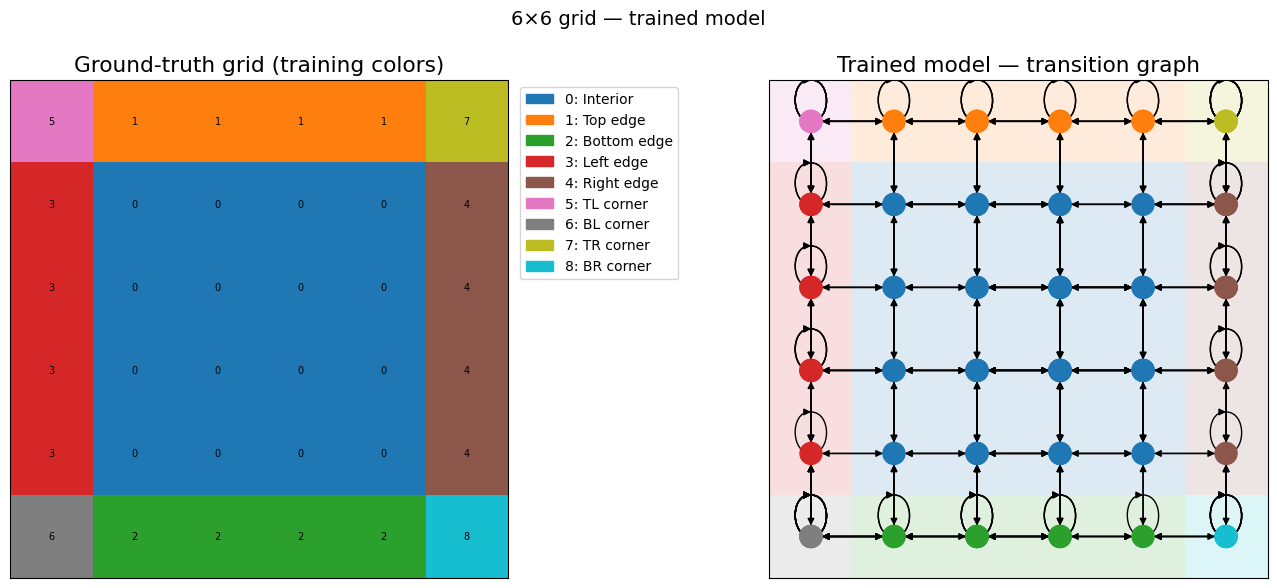

In [5]:
states_train, pos_graph_train = decode_and_build_pos(
    model, x_train, a_train, pos_train
)
print(f'Unique decoded states (training): {len(np.unique(states_train))} / {n_rows * n_cols}')

K = n_obs
cmap_grid = plt.cm.get_cmap('tab10', K)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

show_grid(grid, title='Ground-truth grid (training colors)', ax=axes[0])

ax = axes[1]
ax.imshow(grid, cmap=cmap_grid, vmin=-0.5, vmax=K - 0.5, alpha=0.15,
           extent=[-0.5, n_cols - 0.5, -(n_rows - 0.5), 0.5])
utils.plot_graph(model.counts_matrix, states_train, n_clones,
                  x_max=K - 1, ax=ax, pos=pos_graph_train,
                  node_size=250, threshold=0.0, cmap='tab10')
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-(n_rows - 0.5), 0.5)
ax.set_title('Trained model — transition graph')
ax.set_xticks([]); ax.set_yticks([])
ax.set_aspect('equal')

patches = [mpatches.Patch(color=cmap_grid(i / (K - 1)), label=f'{i}: {obs_names[i]}')
           for i in range(K)]
axes[0].legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

plt.suptitle(f'{n_rows}×{n_cols} grid — trained model', fontsize=14)
plt.tight_layout()
plt.show()

## Color permutation

Define a permutation of the 9 token types.  `perm[k]` is the new token id for
the old token `k`.  The probe agent will observe `perm[original_token]` at each
step — the model has never been trained on this remapping.

Permutation:
  0 (Interior    ) → 2 (Bottom edge) ← changed
  1 (Top edge    ) → 0 (Interior) ← changed
  2 (Bottom edge ) → 3 (Left edge) ← changed
  3 (Left edge   ) → 4 (Right edge) ← changed
  4 (Right edge  ) → 1 (Top edge) ← changed
  5 (TL corner   ) → 6 (BL corner) ← changed
  6 (BL corner   ) → 5 (TL corner) ← changed
  7 (TR corner   ) → 8 (BR corner) ← changed
  8 (BR corner   ) → 7 (TR corner) ← changed


/tmp/ipykernel_1505121/2442828959.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', K)


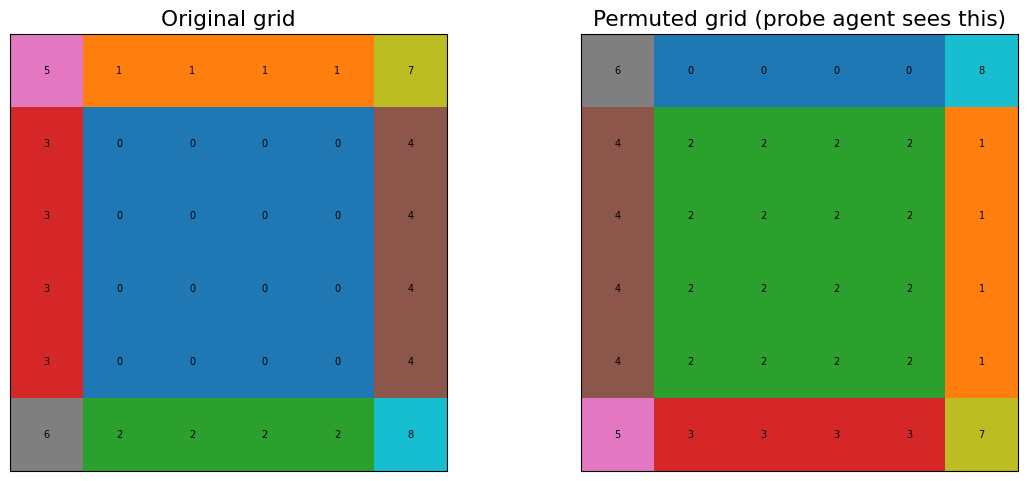

In [6]:
# Permutation: perm[k] = new token id for old token k.
# Edit this list to try different permutations.
#
# Example below: rotate edge types cyclically and swap two corners
#   0→0 (interior unchanged)
#   1→2, 2→3, 3→4, 4→1  (edges rotate)
#   5→6, 6→5  (TL ↔ BL corners swap)
#   7→8, 8→7  (TR ↔ BR corners swap)
perm = np.array([2, 0, 3, 4, 1, 6, 5, 8, 7], dtype=int)

# Verify it is a valid permutation
assert np.all(np.sort(perm) == np.arange(K)), 'perm must be a permutation of 0..K-1'

print('Permutation:')
for k in range(K):
    arrow = ' ← changed' if perm[k] != k else ''
    print(f'  {k} ({obs_names[k]:12s}) → {perm[k]} ({obs_names[perm[k]]}){arrow}')

# Build permuted grid for visualization
grid_permuted = perm[grid]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
show_grid(grid,          title='Original grid', ax=axes[0])
show_grid(grid_permuted, title='Permuted grid (probe agent sees this)', ax=axes[1])
plt.tight_layout()
plt.show()

## Probe walk

Adjust **`n_probe_steps`** to explore the minimum sample requirement.

In [7]:
# ← Adjust this to find the minimum needed for successful rebinding
n_probe_steps = 5_000

In [8]:
# Generate probe walk on the ORIGINAL grid positions, then apply permutation.
# Use novel tokens K..2K-1 so the model has zero prior emission for them —
# this forces the rebinding algorithm to rely purely on transition structure
# rather than spuriously anchoring on in-vocabulary token matches.
a_probe, x_probe_orig, pos_probe = generate_random_walk(
    grid, n_probe_steps, seed=99
)
x_probe = K + perm[x_probe_orig]   # novel tokens K..2K-1 (never seen during training)

# Coverage statistics
visited = set(map(tuple, pos_probe))
cell_counts = {i: int((x_probe_orig == i).sum()) for i in range(K)}
print(f'Probe length     : {n_probe_steps:,}')
print(f'Grid cells visited: {len(visited)} / {n_rows * n_cols}')
print('Observations per region type (original labeling):')
for k, name in enumerate(obs_names):
    print(f'  {k} ({name:12s}): {cell_counts[k]:5d} steps')

Probe length     : 5,000
Grid cells visited: 36 / 36
Observations per region type (original labeling):
  0 (Interior    ):  2210 steps
  1 (Top edge    ):   476 steps
  2 (Bottom edge ):   520 steps
  3 (Left edge   ):   604 steps
  4 (Right edge  ):   573 steps
  5 (TL corner   ):   167 steps
  6 (BL corner   ):   197 steps
  7 (TR corner   ):   107 steps
  8 (BR corner   ):   146 steps


## Rebinding

Run Algorithm 1: leave-one-out slot posteriors → affinity matrix → linear assignment.

In [ ]:
print('Running rebinding...')
emission_rb_vec = model.rebind(
    observations=x_probe,
    actions=a_probe,
    emission_vec=None,   # start from identity (slot j → token j)
    p_surprise=0.1,
    n_iters=1,
    method='hungarian',
)
print('Done.')
offsets = np.hstack(([0], n_clones.cumsum()))
# Build emission matrix for bps / decode.
# The probe observations are in K..2K-1, so the matrix needs K_full = 2*K columns.
K_full = 2 * K
emission_rb_matrix = np.zeros((n_clones.sum(), K_full), dtype=np.float32)
for h in range(n_clones.sum()):
    emission_rb_matrix[h, emission_rb_vec[h]] = 1.0

Running rebinding...
Done.


## Evaluate rebinding quality

In [10]:
# --- Slot-level mapping table ---
# emission_rb_vec values are in K..2K-1 (novel tokens); subtract K to get
# the inferred original color index for display.
print('Rebound emission mapping (slot j → inferred original color):')
print(f'{"Slot":>4}  {"Trained on":>15}  {"Rebound color":>14}  {"Expected":>9}  {"Correct?":>8}')
print('-' * 65)
n_correct = 0
for j in range(K):
    rebound_tok  = int(emission_rb_vec[offsets[j]])   # novel token K+something
    inferred_col = rebound_tok - K                    # back to 0..K-1
    expected_col = int(perm[j])                       # ground-truth target color
    ok = inferred_col == expected_col
    n_correct += int(ok)
    tick = '✓' if ok else '✗'
    print(f'{j:>4}  {obs_names[j]:>15}  {obs_names[inferred_col]:>14}  '
          f'{obs_names[expected_col]:>9}  {tick:>8}')
print(f'\nSlots correctly rebound: {n_correct}/{K}')

# --- BPS comparison ---
# Default (no rebinding): slot j → novel token K+j  (identity mapping, wrong for permuted probe)
default_emission_vec_novel = model.default_emission_vec + K   # (H,)  values in K..2K-1
default_emission_matrix = np.zeros((n_clones.sum(), K_full), dtype=np.float32)
for h in range(n_clones.sum()):
    default_emission_matrix[h, default_emission_vec_novel[h]] = 1.0

print('\nBPS on probe sequence:')
bps_default = model.bps(x_probe, a_probe,
                         emission_matrix=default_emission_matrix).mean()
bps_rebound = model.bps(x_probe, a_probe,
                         emission_matrix=emission_rb_matrix).mean()
print(f'  Training bps (reference)   : {train_bps:.4f}')
print(f'  Probe w/ default emission  : {bps_default:.4f}  (should be high — wrong mapping)')
print(f'  Probe w/ rebound emission  : {bps_rebound:.4f}  (should approach training bps)')

Rebound emission mapping (slot j → inferred original color):
Slot       Trained on   Rebound color   Expected  Correct?
-----------------------------------------------------------------
   0         Interior     Bottom edge  Bottom edge         ✓
   1         Top edge        Interior   Interior         ✓
   2      Bottom edge       Left edge  Left edge         ✓
   3        Left edge      Right edge  Right edge         ✓
   4       Right edge        Top edge   Top edge         ✓
   5        TL corner       BL corner  BL corner         ✓
   6        BL corner       TL corner  TL corner         ✓
   7        TR corner       BR corner  BR corner         ✓
   8        BR corner       TR corner  TR corner         ✓

Slots correctly rebound: 9/9

BPS on probe sequence:
  Training bps (reference)   : 0.0173
  Probe w/ default emission  : nan  (should be high — wrong mapping)
  Probe w/ rebound emission  : 0.0127  (should approach training bps)


## Visualize rebound graph

Decode the probe walk under the rebound emission.  If rebinding succeeded the
graph should have the same spatial structure as the trained model.

Unique states decoded (probe, rebound emission): 86


/tmp/ipykernel_1505121/2442828959.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', K)


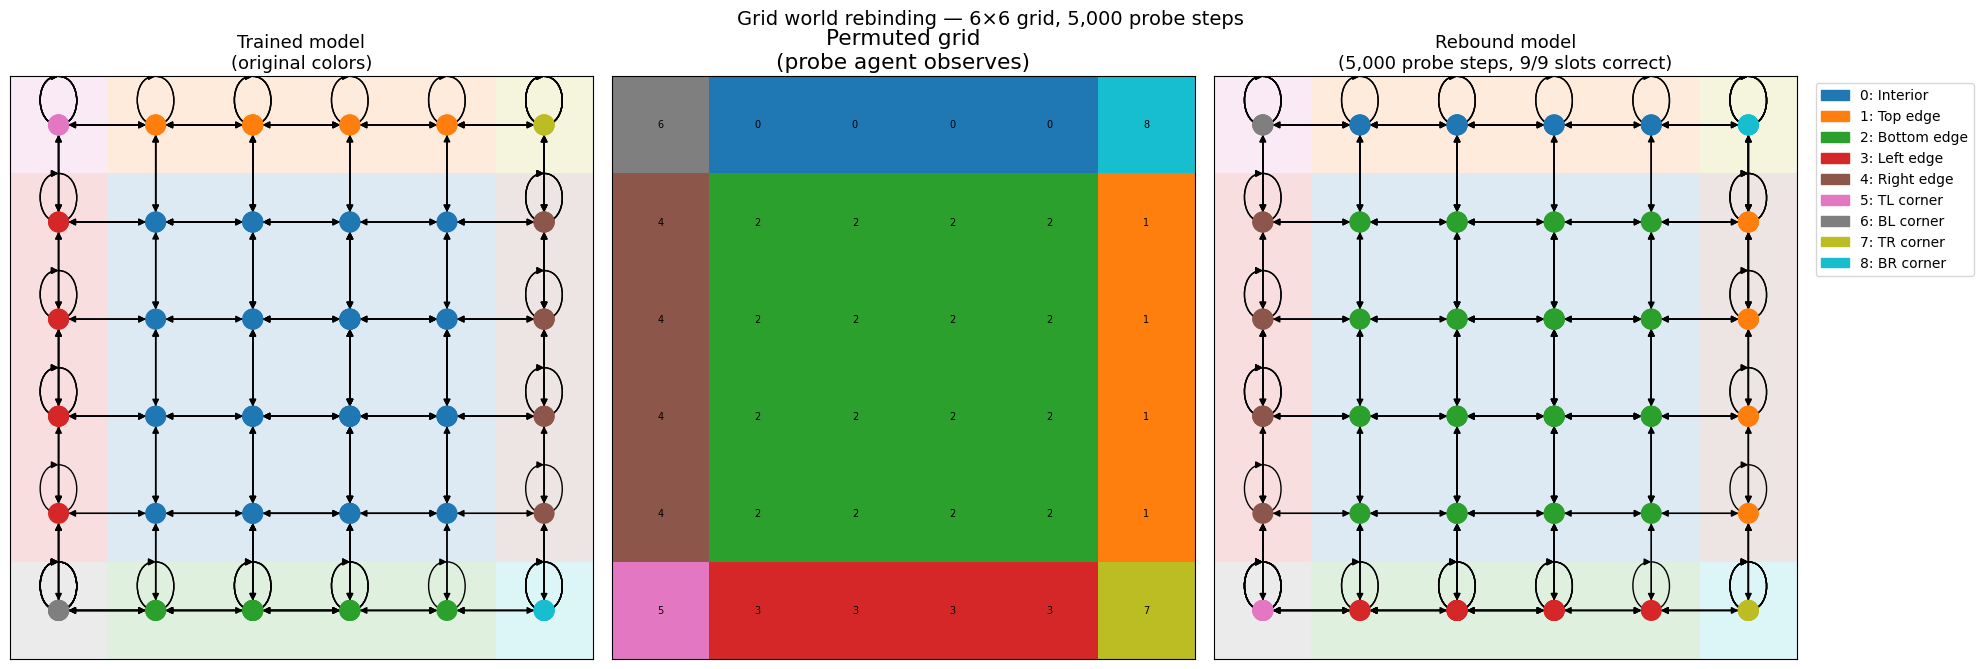

In [11]:
states_rb, pos_graph_rb = decode_and_build_pos(
    model, x_probe, a_probe, pos_probe,
    emission_matrix=emission_rb_matrix,
)
print(f'Unique states decoded (probe, rebound emission): {len(np.unique(states_rb))}')

# Node colors: color by the REBOUND inferred original color (0..K-1) for each state.
# emission_rb_vec is in K..2K-1, so subtract K to map back to the colormap range.
v_rb = np.unique(states_rb)
node_labels_rb = emission_rb_vec[v_rb] - K   # (n_unique_states,) in 0..K-1

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Panel 1: original trained graph ---
ax = axes[0]
ax.imshow(grid, cmap=cmap_grid, vmin=-0.5, vmax=K - 0.5, alpha=0.15,
           extent=[-0.5, n_cols - 0.5, -(n_rows - 0.5), 0.5])
utils.plot_graph(model.counts_matrix, states_train, n_clones,
                  x_max=K - 1, ax=ax, pos=pos_graph_train,
                  node_size=200, threshold=0.0, cmap='tab10')
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-(n_rows - 0.5), 0.5)
ax.set_title('Trained model\n(original colors)', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.set_aspect('equal')

# --- Panel 2: permuted grid (what probe agent sees) ---
show_grid(grid_permuted, title=f'Permuted grid\n(probe agent observes)', ax=axes[1])

# --- Panel 3: rebound graph ---
ax = axes[2]
ax.imshow(grid, cmap=cmap_grid, vmin=-0.5, vmax=K - 0.5, alpha=0.15,
           extent=[-0.5, n_cols - 0.5, -(n_rows - 0.5), 0.5])
utils.plot_graph(model.counts_matrix, states_rb, n_clones,
                  x_max=K - 1, ax=ax, pos=pos_graph_rb,
                  node_size=200, threshold=0.0, cmap='tab10',
                  node_labels=node_labels_rb)
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-(n_rows - 0.5), 0.5)
ax.set_title(f'Rebound model\n({n_probe_steps:,} probe steps, '
              f'{n_correct}/{K} slots correct)', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.set_aspect('equal')

patches = [mpatches.Patch(color=cmap_grid(i / (K - 1)), label=f'{i}: {obs_names[i]}')
           for i in range(K)]
axes[2].legend(handles=patches, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.suptitle(
    f'Grid world rebinding — {n_rows}×{n_cols} grid, {n_probe_steps:,} probe steps',
    fontsize=14,
)
plt.tight_layout()
plt.show()

## Convergence curves (training)

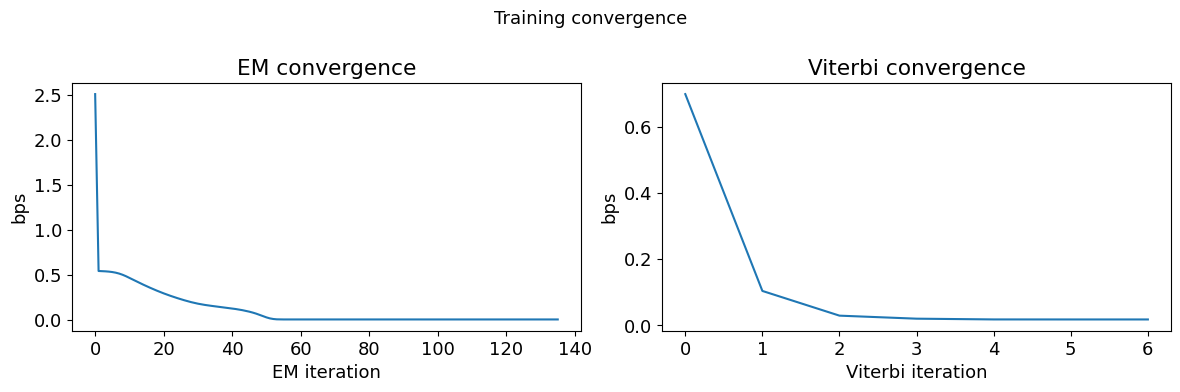

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(conv_em)
axes[0].set_xlabel('EM iteration')
axes[0].set_ylabel('bps')
axes[0].set_title('EM convergence')
axes[1].plot(conv_vit)
axes[1].set_xlabel('Viterbi iteration')
axes[1].set_ylabel('bps')
axes[1].set_title('Viterbi convergence')
plt.suptitle('Training convergence', fontsize=13)
plt.tight_layout()
plt.show()

## Rebinding — ML argmax comparison

Re-run rebinding on the same probe data using per-slot argmax instead of the
Hungarian algorithm.  Each slot independently picks its highest-affinity token;
no injectivity is enforced, so two slots can collide on the same token.

In [13]:
print('Running rebinding (argmax)...')
emission_ml_vec = model.rebind(
    observations=x_probe,
    actions=a_probe,
    emission_vec=None,
    p_surprise=0.1,
    n_iters=1,
    method='argmax',
)
print('Done.')

emission_ml_matrix = np.zeros((n_clones.sum(), K_full), dtype=np.float32)
for h in range(n_clones.sum()):
    emission_ml_matrix[h, emission_ml_vec[h]] = 1.0

Running rebinding (argmax)...
Done.


In [14]:
# --- Slot mapping table with collision detection ---
print('Rebound emission mapping (argmax):')
print(f'{"Slot":>4}  {"Trained on":>15}  {"Rebound color":>14}  {"Expected":>9}  {"Correct?":>8}')
print('-' * 65)
n_correct_ml = 0
assigned_tokens = {}   # token → list of slots that picked it
for j in range(K):
    rebound_tok  = int(emission_ml_vec[offsets[j]])
    inferred_col = rebound_tok - K
    expected_col = int(perm[j])
    ok = inferred_col == expected_col
    n_correct_ml += int(ok)
    assigned_tokens.setdefault(rebound_tok, []).append(j)
    tick = '✓' if ok else '✗'
    print(f'{j:>4}  {obs_names[j]:>15}  {obs_names[inferred_col]:>14}  '
          f'{obs_names[expected_col]:>9}  {tick:>8}')

collisions = {tok: slots for tok, slots in assigned_tokens.items() if len(slots) > 1}
print(f'\nSlots correctly rebound : {n_correct_ml}/{K}')
if collisions:
    print(f'Token collisions        : {len(collisions)} token(s) claimed by multiple slots')
    for tok, slots in collisions.items():
        print(f'  novel token {tok} ({obs_names[tok - K]}) claimed by slots {slots}')
else:
    print('Token collisions        : none')

# --- BPS comparison ---
bps_ml = model.bps(x_probe, a_probe, emission_matrix=emission_ml_matrix).mean()
print(f'\nBPS comparison (probe sequence):')
print(f'  Training (reference)   : {train_bps:.4f}')
print(f'  Hungarian rebinding    : {bps_rebound:.4f}')
print(f'  Argmax rebinding       : {bps_ml:.4f}')

Rebound emission mapping (argmax):
Slot       Trained on   Rebound color   Expected  Correct?
-----------------------------------------------------------------
   0         Interior     Bottom edge  Bottom edge         ✓
   1         Top edge        Interior   Interior         ✓
   2      Bottom edge       Left edge  Left edge         ✓
   3        Left edge      Right edge  Right edge         ✓
   4       Right edge        Top edge   Top edge         ✓
   5        TL corner       BL corner  BL corner         ✓
   6        BL corner       TL corner  TL corner         ✓
   7        TR corner       BR corner  BR corner         ✓
   8        BR corner       TR corner  TR corner         ✓

Slots correctly rebound : 9/9
Token collisions        : none

BPS comparison (probe sequence):
  Training (reference)   : 0.0173
  Hungarian rebinding    : 0.0127
  Argmax rebinding       : 0.0127


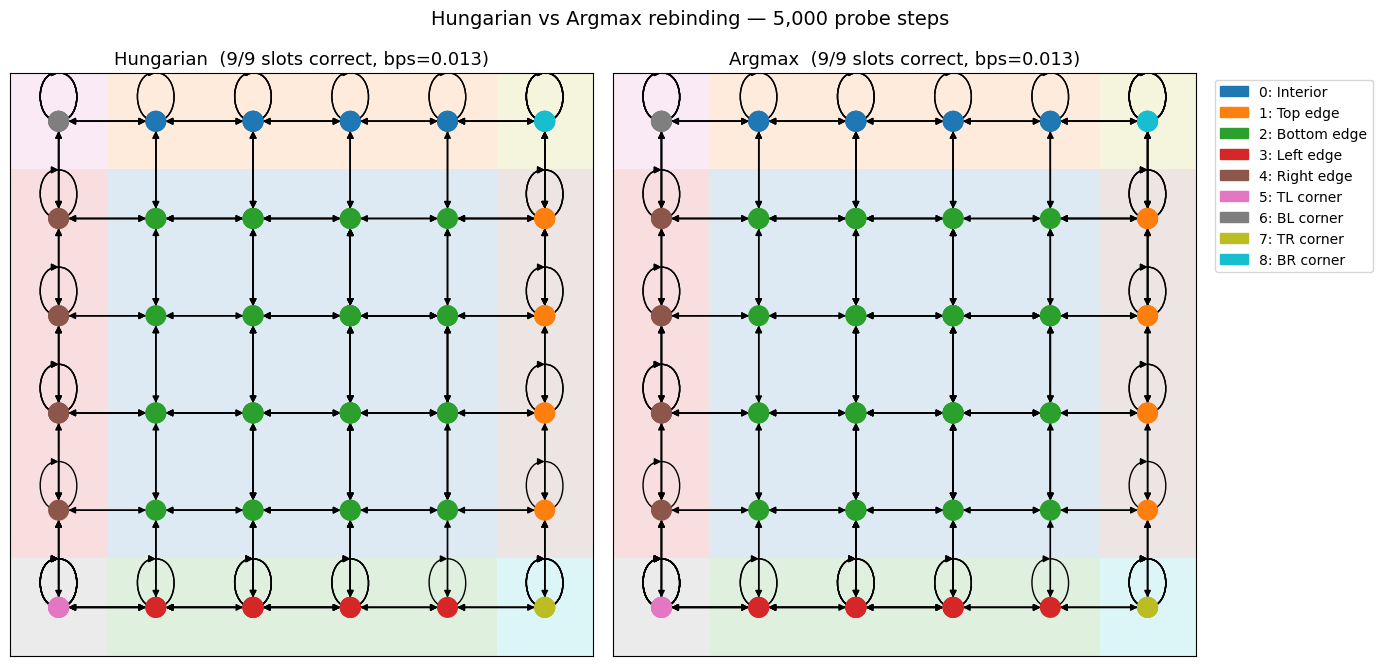

In [15]:
states_ml, pos_graph_ml = decode_and_build_pos(
    model, x_probe, a_probe, pos_probe,
    emission_matrix=emission_ml_matrix,
)

v_ml = np.unique(states_ml)
node_labels_ml = emission_ml_vec[v_ml] - K

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
ax.imshow(grid, cmap=cmap_grid, vmin=-0.5, vmax=K - 0.5, alpha=0.15,
           extent=[-0.5, n_cols - 0.5, -(n_rows - 0.5), 0.5])
utils.plot_graph(model.counts_matrix, states_rb, n_clones,
                  x_max=K - 1, ax=ax, pos=pos_graph_rb,
                  node_size=200, threshold=0.0, cmap='tab10',
                  node_labels=node_labels_rb)
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-(n_rows - 0.5), 0.5)
ax.set_title(f'Hungarian  ({n_correct}/{K} slots correct, bps={bps_rebound:.3f})', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.set_aspect('equal')

ax = axes[1]
ax.imshow(grid, cmap=cmap_grid, vmin=-0.5, vmax=K - 0.5, alpha=0.15,
           extent=[-0.5, n_cols - 0.5, -(n_rows - 0.5), 0.5])
utils.plot_graph(model.counts_matrix, states_ml, n_clones,
                  x_max=K - 1, ax=ax, pos=pos_graph_ml,
                  node_size=200, threshold=0.0, cmap='tab10',
                  node_labels=node_labels_ml)
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(-(n_rows - 0.5), 0.5)
ax.set_title(f'Argmax  ({n_correct_ml}/{K} slots correct, bps={bps_ml:.3f})', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.set_aspect('equal')

patches = [mpatches.Patch(color=cmap_grid(i / (K - 1)), label=f'{i}: {obs_names[i]}')
           for i in range(K)]
axes[1].legend(handles=patches, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.suptitle(f'Hungarian vs Argmax rebinding — {n_probe_steps:,} probe steps', fontsize=14)
plt.tight_layout()
plt.show()